# NFL Spread Analyzer & Betting Market Research
### Built by Shaan Jagtiani| Python, Pandas, The Odds API, SciPy

---

## About This Project
This is my first Sports Trading project, built over the summer of 2026 as part of my goal of breaking into sports trading. I recently graduated from the University of Michigan with a degree in Sports Management and have been self-teaching Python and data analysis to build the technical skills needed for a career in sports betting markets.

I chose this project specifically because it sits at the intersection of what I already understand: how betting markets work and how books balance their books, and what I needed to prove I could do: pull real data, clean it, analyze it, and draw statistically tested conclusions from it.

Everything in this notebook was built from scratch using live API data from The Odds API and a historical NFL dataset covering 35 years of games. The analysis covers live book comparison, juice and hold percentage calculation, and three independently tested market inefficiency findings backed by binomial significance testing.

---

## Project Overview
**Part 1: Live Market Analysis:** Pulls current NFL spread lines from multiple sportsbooks via API and compares juice and hold percentages across books to identify pricing inefficiencies.

**Part 2: Historical Market Analysis:** Uses 9,455 NFL games (1990–2024) to test whether structural patterns exist in how the market prices favorites, rest advantages, and scheduling disadvantages.

**Core question:** Is the NFL betting market efficient, and if not, where does it break down?

---

In [ ]:
# ============================================================
# NFL Spread Analyzer & Betting Market Research
# Cell 1: Imports & API Connection Test
# ============================================================

# --- IMPORTS ---
import requests   
import pandas as pd  

# --- API CONFIGURATION ---
API_KEY = "YOUR_API_KEY_HERE"  # get a free key at the-odds-api.com

# --- ENDPOINT ---
url = "https://api.the-odds-api.com/v4/sports/americanfootball_nfl/odds"

# --- PARAMETERS ---
# filters I send with the request to get exactly the data I want
params = {
    "apiKey": API_KEY,          # authenticates my request
    "regions": "us",            # US sportsbooks only (DraftKings, FanDuel, etc.)
    "markets": "spreads",       # spread lines specifically
    "oddsFormat": "american",   # returns lines in american odds: -110, +350
    "dateFormat": "iso"         # readable timestamp format
}

# --- MAKE THE REQUEST ---
# sends the call to the API and waits for a response
response = requests.get(url, params=params)

# --- PARSE THE RESPONSE ---
# converts the raw JSON response into a Python object we can work with
data = response.json()

# --- RESULTS ---
print(f"Status: {response.status_code}")                              
print(f"Requests remaining: {response.headers.get('x-requests-remaining')}")  # track usage
print(f"Games found: {len(data)}")                                    

Status: 200
Requests remaining: 494
Games found: 75


## Cell 1 Results: API Connection
The API returned **75 NFL games** with live spread lines across all major US sportsbooks. Status 200 confirms the connection is working.

Before I can do anything with this data I need to understand its structure. The API returns nested JSON: Data is stored inside layers like Russian dolls. The next cell prints one raw game so I can see exactly what fields we have to work with before writing any parsing code.

In [ ]:
# ============================================================
# NFL Spread Analyzer & Betting Market Research
# Cell 2: Explore the Raw Data Structure
# ============================================================

# --- ONE GAME Preview ---
# the API returns a list of games, each game is a dictionary
# print the first game to understand what fields we get back
import json
print(json.dumps(data[0], indent=2))

{
  "id": "8c94552d022acec4a0458d70c19d3da9",
  "sport_key": "americanfootball_nfl",
  "sport_title": "NFL",
  "commence_time": "2026-09-10T00:15:00Z",
  "home_team": "Seattle Seahawks",
  "away_team": "New England Patriots",
  "bookmakers": [
    {
      "key": "draftkings",
      "title": "DraftKings",
      "last_update": "2026-05-17T22:24:24Z",
      "markets": [
        {
          "key": "spreads",
          "last_update": "2026-05-17T22:24:24Z",
          "outcomes": [
            {
              "name": "New England Patriots",
              "price": -105,
              "point": 3.5
            },
            {
              "name": "Seattle Seahawks",
              "price": -115,
              "point": -3.5
            }
          ]
        }
      ]
    },
    {
      "key": "betus",
      "title": "BetUS",
      "last_update": "2026-05-17T22:25:03Z",
      "markets": [
        {
          "key": "spreads",
          "last_update": "2026-05-17T22:25:03Z",
          "outcomes":

## Cell 2 Results: Raw Data Structure
Each game contains the game info at the top level (teams, date, ID) and then a nested list of bookmakers. Inside each bookmaker is another nested list of markets, and inside each market is a list of two outcomes, one per team.

The key fields I need are buried inside: `bookmakers → markets → outcomes → point` (the spread) and `price` (the juice). The next cell flattens all of this into a clean table with one row per game per bookmaker.

In [ ]:
# ============================================================
# NFL Spread Analyzer & Betting Market Research
# Cell 3: Parse API Data into a Clean DataFrame
# ============================================================

# a list to store each row before I turn it into a table
rows = []

# loop through every game the API returned
for game in data:

    # extract the top-level game info
    game_id       = game["id"]
    home_team     = game["home_team"]
    away_team     = game["away_team"]
    commence_time = game["commence_time"]

    # loop through each bookmaker for this game
    for bookmaker in game["bookmakers"]:
        book_name   = bookmaker["title"]
        last_update = bookmaker["last_update"]

        # dig into the spreads market
        spreads = bookmaker["markets"][0]["outcomes"]

        # outcomes has two items: home team and away team
        for outcome in spreads:
            if outcome["name"] == home_team:
                home_spread = outcome["point"]   # e.g. -2.5
                home_price  = outcome["price"]   # e.g. -120
            else:
                away_spread = outcome["point"]   # e.g. +2.5
                away_price  = outcome["price"]   # e.g. +100

        # package everything into one clean row (a dictionary)
        rows.append({
            "game_id"      : game_id,
            "commence_time": commence_time,
            "home_team"    : home_team,
            "away_team"    : away_team,
            "bookmaker"    : book_name,
            "last_update"  : last_update,
            "home_spread"  : home_spread,
            "home_price"   : home_price,
            "away_spread"  : away_spread,
            "away_price"   : away_price,
        })

# convert the list of dictionaries into a pandas DataFrame
df = pd.DataFrame(rows)

# display the first 10 rows so I can see what I built
df.head(10)

,game_id,commence_time,home_team,away_team,bookmaker,last_update,home_spread,home_price,away_spread,away_price
0,8c94552d022acec4a0458d70c19d3da9,2026-09-10T00:15:00Z,Seattle Seahawks,New England Patriots,DraftKings,2026-05-17T22:24:24Z,-3.5,-115,3.5,-105
1,8c94552d022acec4a0458d70c19d3da9,2026-09-10T00:15:00Z,Seattle Seahawks,New England Patriots,BetUS,2026-05-17T22:25:03Z,-4.5,-115,4.5,-105
2,8c94552d022acec4a0458d70c19d3da9,2026-09-10T00:15:00Z,Seattle Seahawks,New England Patriots,FanDuel,2026-05-17T22:24:42Z,-4.5,-105,4.5,-115
3,8c94552d022acec4a0458d70c19d3da9,2026-09-10T00:15:00Z,Seattle Seahawks,New England Patriots,LowVig.ag,2026-05-17T22:24:05Z,-4.5,-110,4.5,100
4,8c94552d022acec4a0458d70c19d3da9,2026-09-10T00:15:00Z,Seattle Seahawks,New England Patriots,BetOnline.ag,2026-05-17T22:25:02Z,-4.5,-115,4.5,-105
5,8c94552d022acec4a0458d70c19d3da9,2026-09-10T00:15:00Z,Seattle Seahawks,New England Patriots,BetRivers,2026-05-17T22:25:02Z,-4.5,-112,4.5,-112
6,8c94552d022acec4a0458d70c19d3da9,2026-09-10T00:15:00Z,Seattle Seahawks,New England Patriots,BetMGM,2026-05-17T22:24:04Z,-4.5,-115,4.5,-105
7,8c94552d022acec4a0458d70c19d3da9,2026-09-10T00:15:00Z,Seattle Seahawks,New England Patriots,Bovada,2026-05-17T22:24:47Z,-4.5,-110,4.5,-110
8,acc580d74344ea3b31bbcdd057fe6a9c,2026-09-11T00:35:00Z,Los Angeles Rams,San Francisco 49ers,DraftKings,2026-05-17T22:24:24Z,-2.5,-120,2.5,100
9,acc580d74344ea3b31bbcdd057fe6a9c,2026-09-11T00:35:00Z,Los Angeles Rams,San Francisco 49ers,BetMGM,2026-05-17T22:24:04Z,-2.5,-115,2.5,-105


## Cell 3 Results: Clean DataFrame
I successfully flattened the nested JSON into a clean table with one row per game per bookmaker. Each row shows the spread and juice offered by a single book for a single game.

A few things stand out immediately. BetUS has the Seahawks at -4.5 while every other book has them at -3.5 — a full point difference on the same game. That half to full point difference can be the difference between winning and losing a bet that lands exactly on the number.

In [ ]:
# ============================================================
# NFL Spread Analyzer & Betting Market Research
# Cell 4: Best Line Finder — which book has the best price?
# ============================================================

# --- WHY WE'RE DOING THIS ---
# A sharp bettor always shops for the best line
# This cell finds the best home and away price for each game

best_lines = []

# group the dataframe by game so I can analyze each matchup separately
for game_id, group in df.groupby("game_id"):

    home_team = group["home_team"].iloc[0]   # iloc[0] = first row's value
    away_team = group["away_team"].iloc[0]
    commence  = group["commence_time"].iloc[0]

    # find the best (highest) price for the home team across all books
    # higher price = better deal for the bettor (-105 is better than -120)
    best_home_idx   = group["home_price"].idxmax()   # idxmax = index of the max value
    best_home_book  = group.loc[best_home_idx, "bookmaker"]
    best_home_price = group.loc[best_home_idx, "home_price"]
    best_home_spread= group.loc[best_home_idx, "home_spread"]

    # same for the away team
    best_away_idx   = group["away_price"].idxmax()
    best_away_book  = group.loc[best_away_idx, "bookmaker"]
    best_away_price = group.loc[best_away_idx, "away_price"]
    best_away_spread= group.loc[best_away_idx, "away_spread"]

    best_lines.append({
        "game"            : f"{away_team} @ {home_team}",
        "kickoff"         : commence[:10],   # just the date, not full timestamp
        "best_home_book"  : best_home_book,
        "home_spread"     : best_home_spread,
        "best_home_price" : best_home_price,
        "best_away_book"  : best_away_book,
        "away_spread"     : best_away_spread,
        "best_away_price" : best_away_price,
    })

# convert to dataframe and display
best_df = pd.DataFrame(best_lines)
best_df

,game,kickoff,best_home_book,home_spread,best_home_price,best_away_book,away_spread,best_away_price
0,Minnesota Vikings @ Chicago Bears,2026-09-20,DraftKings,-3.5,-105,DraftKings,3.5,-115
1,Kansas City Chiefs @ Miami Dolphins,2026-09-27,DraftKings,7.0,-105,DraftKings,-7.0,-115
2,Cleveland Browns @ Tampa Bay Buccaneers,2026-09-20,DraftKings,-5.5,-110,DraftKings,5.5,-110
3,New York Jets @ Detroit Lions,2026-09-27,DraftKings,-9.5,-110,DraftKings,9.5,-110
4,New York Jets @ Chicago Bears,2026-10-04,DraftKings,-8.5,-110,DraftKings,8.5,-110
...,...,...,...,...,...,...,...,...
70,Tennessee Titans @ Baltimore Ravens,2026-10-04,DraftKings,-8.5,-110,DraftKings,8.5,-110
71,Minnesota Vikings @ Tampa Bay Buccaneers,2026-09-27,DraftKings,-1.5,-110,DraftKings,1.5,-110
72,Philadelphia Eagles @ Tennessee Titans,2026-09-20,DraftKings,4.5,-110,DraftKings,-4.5,-110
73,New York Giants @ Washington Commanders,2026-10-11,DraftKings,-2.5,-110,DraftKings,2.5,-110


## Cell 4 Results: Best Line Finder
This table surfaces the single best price available on each side of every game across all books. For most games DraftKings is showing up as the best price: which makes sense as they're aggressive with pricing to acquire customers.

In [ ]:
# ============================================================
# NFL Spread Analyzer & Betting Market Research
# Cell 5: Book Comparison Table with Juice & Hold %
# ============================================================
# This table compares every sportsbook's price on a single game
# and shows how much each book is charging in vig (juice)
# Hold % tells us how much the book expects to keep long-term
# A fair market = 100% hold. Anything above = book's profit margin
# ============================================================


# ---- PICK THE GAME WE WANT TO ANALYZE ----
# filter the main dataframe down to just one matchup
game_filter = (
    (df["home_team"] == "Kansas City Chiefs") &
    (df["away_team"] == "Denver Broncos")
)
game_df = df[game_filter].copy()


# ---- JUICE DIFFERENCE VS STANDARD ----
# standard depends on the price itself, not the spread
# if a book prices a side at negative odds = standard is -110
# if a book prices a side at positive odds = standard is +100

def vs_standard(price):
    if price < 0:
        return price - (-110)   # e.g. -120 vs -110 = -10
    else:
        return price - 100      # e.g. +105 vs +100 = +5

game_df["home_vs_standard"] = game_df["home_price"].apply(vs_standard)
game_df["away_vs_standard"] = game_df["away_price"].apply(vs_standard)


# ---- TOTAL JUICE ----
# add both sides together to get the total vig for the game
# standard = -110 + -110 = -220
# lower (less negative) = cheaper book
game_df["total_juice"] = game_df["home_price"] + game_df["away_price"]


# ---- HOLD PERCENTAGE ----
# converts american odds to implied probability, then adds both sides
# a fair market adds to exactly 100%
# anything above 100% is the bookmaker's built-in edge

def american_to_implied_prob(odds):
    # negative odds = favorites (e.g. -120)
    # formula: abs(odds) / (abs(odds) + 100)
    if odds < 0:
        return abs(odds) / (abs(odds) + 100)
    # positive odds = underdogs (e.g. +110)
    # formula: 100 / (odds + 100)
    else:
        return 100 / (odds + 100)

# apply the conversion function to every row in both price columns
game_df["home_implied"] = game_df["home_price"].apply(american_to_implied_prob)
game_df["away_implied"] = game_df["away_price"].apply(american_to_implied_prob)

# sum both implied probs and multiply by 100 to get a percentage
game_df["hold_pct"] = (game_df["home_implied"] + game_df["away_implied"]) * 100


# ---- BUILD THE DISPLAY TABLE ----
# select only the columns I want to show and rename them cleanly
table = game_df[[
    "bookmaker",
    "home_spread", "home_price", "home_vs_standard",
    "away_spread", "away_price", "away_vs_standard",
    "total_juice", "hold_pct"
]].copy()

table.columns = [
    "Bookmaker",
    "Chiefs Spread", "Chiefs Price", "vs -110",
    "Broncos Spread", "Broncos Price", "vs -110 ",
    "Total Juice", "Hold %"
]

# sort by hold % so the cheapest books (lowest vig) appear at the top
table = table.sort_values("Hold %", ascending=True).reset_index(drop=True)


# ---- COLOR CODING FUNCTIONS ----
# these functions apply background colors to cells based on their value
# pandas .map() runs these functions on every cell in a specified column

def color_vs_standard(val):
    # positive = better than standard = green
    # negative = worse than standard = red
    if val > 0:
        return "background-color: #1a7a1a; color: white"
    elif val < 0:
        return "background-color: #7a1a1a; color: white"
    else:
        return ""

def color_total_juice(val):
    # higher (less negative) = cheaper book = green
    if val >= -220:
        return "background-color: #1a7a1a; color: white"
    elif val <= -230:
        return "background-color: #7a1a1a; color: white"
    else:
        return ""

def color_hold(val):
    # under 104% = cheap book = green
    # over 106% = expensive book = red
    if val < 104:
        return "background-color: #1a7a1a; color: white"
    elif val > 106:
        return "background-color: #7a1a1a; color: white"
    else:
        return ""


# ---- STYLE AND DISPLAY ----
# pandas Styler applies visual formatting to the dataframe for display
styled = (
    table.style
    .map(color_vs_standard, subset=["vs -110", "vs -110 "])
    .map(color_total_juice, subset=["Total Juice"])
    .map(color_hold, subset=["Hold %"])
    .format({
        "Chiefs Spread": "{:.1f}",    # 1 decimal place e.g. -2.5
        "Broncos Spread": "{:.1f}",   # 1 decimal place e.g. 2.5
        "Hold %": "{:.2f}%"           # 2 decimal places with % sign
    })
    .set_properties(**{
        "text-align": "center",
        "font-size": "13px",
        "border": "1px solid #444"
    })
    .set_table_styles([{
        "selector": "th",
        "props": [
            ("background-color", "#2a2a2a"),
            ("color", "white"),
            ("font-size", "13px"),
            ("text-align", "center"),
            ("padding", "8px")
        ]
    }])
)

styled

,Bookmaker,Chiefs Spread,Chiefs Price,vs -110,Broncos Spread,Broncos Price,vs -110,Total Juice,Hold %
0,LowVig.ag,-2.5,-116,-6,2.5,105,5,-11,102.48%
1,DraftKings,-2.5,-120,-10,2.5,100,0,-20,104.55%
2,BetOnline.ag,-2.5,-120,-10,2.5,100,0,-20,104.55%
3,Bovada,-2.5,-120,-10,2.5,100,0,-20,104.55%
4,FanDuel,-2.5,-110,0,2.5,-110,0,-220,104.76%
5,BetMGM,-3.0,-110,0,3.0,-110,0,-220,104.76%
6,BetUS,-3.0,-110,0,3.0,-110,0,-220,104.76%
7,BetRivers,-2.5,-117,-7,2.5,-107,3,-224,105.61%


## Cell 5 Results: Book Comparison Table (Chiefs vs Broncos)
This table breaks down every book's pricing on a single game with three analytical layers: juice vs standard, total juice, and hold percentage.

I selected the Chiefs vs Broncos as the example game because it had the most bookmakers offering lines, giving the richest comparison across books.

**LowVig.ag (Row 0)** is the cheapest book at 102.48% hold — meaning if equal money came in on both sides they'd only keep 2.48 cents per dollar wagered. Every other book is above 104%.

**BetRivers (Row 7)** is the most expensive at 105.61% hold with the worst price on the Chiefs side (-117). I'd avoid this book for this game entirely.

**BetMGM and BetUS (Rows 5-6)** have the Chiefs at -3.0 instead of -2.5 — a full half point difference. In a game decided by a field goal, that half point is the difference between a push and a loss.

**Hold % explained:** I convert each price to implied probability using the standard American odds formula, sum both sides, and multiply by 100. A perfectly efficient market = 100%. Every book charges above that — the difference is their built-in profit margin. LowVig lives up to its name.

---
*Part 1 complete, I've built a live multi-book spread comparison tool pulling from a real API. Part 2 shifts to historical analysis using 9,455 NFL games from 1990–2024.*

---

In [ ]:
# ============================================================
# NFL Spread Analyzer & Betting Market Research
# Cell 6: Load & Explore Historical NFL Data
# ============================================================
# I loaded a dataset of historical NFL games with scores and spread lines
# Note: this dataset contains one line per game, not separate opening
# and closing lines — true CLV requires both, which is a limitation
# discussed at the end of this notebook
# ============================================================

# ---- LOAD THE CSV ----
nfl = pd.read_csv("spreadspoke_scores.csv")

# ---- BASIC EXPLORATION ----
# Understand its shape first

print(f"Rows: {nfl.shape[0]}")        # how many games
print(f"Columns: {nfl.shape[1]}")     # how many fields per game
print(f"\nColumn names:\n{list(nfl.columns)}")   # what fields exist
print(f"\nDate range: {nfl['schedule_date'].min()} to {nfl['schedule_date'].max()}")

Rows: 14371
Columns: 17

Column names:
['schedule_date', 'schedule_season', 'schedule_week', 'schedule_playoff', 'team_home', 'score_home', 'score_away', 'team_away', 'team_favorite_id', 'spread_favorite', 'over_under_line', 'stadium', 'stadium_neutral', 'weather_temperature', 'weather_wind_mph', 'weather_humidity', 'weather_detail']

Date range: 1/1/1967 to 9/9/2024


## Cell 6 Results: Historical Data Loaded
The dataset contains 14,371 NFL games dating back to 1967 with 17 fields including scores, spread lines, weather, and stadium information.

One important limitation I discovered early: this dataset contains a single spread line per game, not separate opening and closing lines. True CLV analysis requires both: you need to know where the line opened and where it closed to measure line movement. With only one line available I pivoted the historical analysis toward cover rate patterns and situational analysis, which is still directly relevant to trading but is different from pure CLV tracking.

I filtered to 1990+ for the analysis since pre-1990 NFL operated under different rules and competitive balance, making historical comparisons less meaningful for modern market analysis.

In [ ]:
# ============================================================
# NFL Spread Analyzer & Betting Market Research
# Cell 7: Clean & Prepare Historical Data for Analysis
# ============================================================
# Before calculating anything I need to clean the data
# This means filtering to relevant seasons, handling missing values,
# and engineering new columns I'll need for the analysis
# ============================================================

# ---- FILTER TO MODERN ERA ----
# pre-1990 NFL is a different game — different rules, different style
# I'll focus on 1990 onwards for relevance
nfl["schedule_date"] = pd.to_datetime(nfl["schedule_date"])
nfl_modern = nfl[nfl["schedule_season"] >= 1990].copy()
print(f"Games after 1990 filter: {len(nfl_modern)}")

# ---- DROP ROWS WITH MISSING SPREAD DATA ----
nfl_modern = nfl_modern.dropna(subset=["spread_favorite"])
print(f"Games with valid spread data: {len(nfl_modern)}")

# ---- DROP ROWS WITH MISSING SCORES ----
nfl_modern = nfl_modern.dropna(subset=["score_home", "score_away"])
print(f"Games with valid scores: {len(nfl_modern)}")

# ---- TEAM NAME TO ABBREVIATION MAPPING ----
# team_favorite_id uses abbreviations (e.g. "ATL")
# but team_home and team_away use full names (e.g. "Atlanta Falcons")
# I mapped them to match correctly
name_to_abbr = {
    "Arizona Cardinals": "ARI", "Atlanta Falcons": "ATL",
    "Baltimore Ravens": "BAL", "Buffalo Bills": "BUF",
    "Carolina Panthers": "CAR", "Chicago Bears": "CHI",
    "Cincinnati Bengals": "CIN", "Cleveland Browns": "CLE",
    "Dallas Cowboys": "DAL", "Denver Broncos": "DEN",
    "Detroit Lions": "DET", "Green Bay Packers": "GB",
    "Houston Texans": "HOU", "Indianapolis Colts": "IND",
    "Jacksonville Jaguars": "JAX", "Kansas City Chiefs": "KC",
    "Las Vegas Raiders": "LV", "Los Angeles Chargers": "LAC",
    "Los Angeles Rams": "LA", "Miami Dolphins": "MIA",
    "Minnesota Vikings": "MIN", "New England Patriots": "NE",
    "New Orleans Saints": "NO", "New York Giants": "NYG",
    "New York Jets": "NYJ", "Philadelphia Eagles": "PHI",
    "Pittsburgh Steelers": "PIT", "San Francisco 49ers": "SF",
    "Seattle Seahawks": "SEA", "Tampa Bay Buccaneers": "TB",
    "Tennessee Titans": "TEN", "Washington Commanders": "WAS",
    "Oakland Raiders": "OAK", "San Diego Chargers": "SD",
    "St. Louis Rams": "STL", "Washington Redskins": "WAS",
    "Washington Football Team": "WAS", "Houston Oilers": "HOU",
    "Tennessee Oilers": "TEN", "Baltimore Colts": "IND",
    "Phoenix Cardinals": "ARI", "Los Angeles Raiders": "OAK"
}

# map full names to abbreviations so I can compare apples to apples
nfl_modern["home_abbr"] = nfl_modern["team_home"].map(name_to_abbr)
nfl_modern["away_abbr"] = nfl_modern["team_away"].map(name_to_abbr)

# ---- ENGINEER KEY COLUMNS ----
# score margin from home team's perspective
nfl_modern["home_margin"] = nfl_modern["score_home"] - nfl_modern["score_away"]

# now compare abbreviations to abbreviations — apples to apples
nfl_modern["home_is_favorite"] = (
    nfl_modern["team_favorite_id"] == nfl_modern["home_abbr"]
)

# spread is always listed as a negative number for the favorite
nfl_modern["spread"] = nfl_modern["spread_favorite"]

# ---- DID THE FAVORITE COVER? ----
nfl_modern["favorite_covered"] = nfl_modern.apply(
    lambda row: (
        row["home_margin"] < row["spread"]        # away is favorite, did they cover?
        if not row["home_is_favorite"]
        else row["home_margin"] > abs(row["spread"])  # home is favorite, did they cover?
    ), axis=1
)

# ---- PREVIEW ----
nfl_modern[["schedule_date", "team_home", "team_away",
            "score_home", "score_away", "spread",
            "home_is_favorite", "favorite_covered"]].head(20)

Games after 1990 filter: 9455
Games with valid spread data: 9455
Games with valid scores: 9455


,schedule_date,team_home,team_away,score_home,score_away,spread,home_is_favorite,favorite_covered
4916,1990-09-09,Atlanta Falcons,Houston Oilers,47,27,-1.0,True,True
4917,1990-09-09,Buffalo Bills,Indianapolis Colts,26,10,-7.5,True,True
4918,1990-09-09,Chicago Bears,Seattle Seahawks,17,0,-6.0,True,True
4919,1990-09-09,Cincinnati Bengals,New York Jets,25,20,-9.0,True,False
4920,1990-09-09,Cleveland Browns,Pittsburgh Steelers,13,3,-3.0,True,True
4921,1990-09-09,Dallas Cowboys,San Diego Chargers,17,14,-3.0,False,False
4922,1990-09-09,Detroit Lions,Tampa Bay Buccaneers,21,38,-6.5,True,False
4923,1990-09-09,Green Bay Packers,Los Angeles Rams,36,24,-3.5,False,False
4924,1990-09-09,Kansas City Chiefs,Minnesota Vikings,24,21,-1.5,False,False
4925,1990-09-09,Los Angeles Raiders,Denver Broncos,14,9,-1.5,False,False


## Cell 7 Results: Data Cleaning & Engineering
After filtering to 1990+ and dropping games with missing spread or score data, I have **9,455 games**: a clean, complete dataset with no gaps.

Three key columns I engineered:

**home_is_favorite** — the dataset stores the favorite as a team abbreviation (e.g. "ATL") while team names are stored as full names (e.g. "Atlanta Falcons"). I built a mapping dictionary to convert full names to abbreviations so the comparison works correctly across all 35 seasons including historical franchises like the Houston Oilers and Phoenix Cardinals.

**home_margin** — simply score_home minus score_away. A positive number means the home team won, negative means they lost.

**favorite_covered** — the core column for all analysis that follows. If the home team is the favorite, they covered if their margin exceeded the absolute value of the spread. If the away team is the favorite, they covered if the home margin was less than the spread. True/False for every game.

I sanity checked the logic manually on several rows: Atlanta won 47-27 against Houston with a -1.0 spread, margin of +20, correctly flagged as covered. Dallas won 17-14 against San Diego with a -3.0 spread but San Diego was the away favorite, they lost so correctly flagged as not covered.

---
*With the data cleaned and engineered, Part 2 analysis begins below.*

---

In [ ]:
# ============================================================
# NFL Spread Analyzer & Betting Market Research
# Cell 8: Cover Rate Analysis
# ============================================================
# Now I analyze the data to find meaningful patterns
# Which teams cover the most? Do favorites cover at a rate
# that justifies betting them? What does the data say?
# ============================================================

# ---- OVERALL FAVORITE COVER RATE ----
# if favorites covered more than 50% of the time
# there would be a systematic bias in the market
overall_cover_rate = nfl_modern["favorite_covered"].mean() * 100
print(f"Overall favorite cover rate (1990-2024): {overall_cover_rate:.1f}%")
print(f"Total games analyzed: {len(nfl_modern)}")

# ---- COVER RATE BY SPREAD BUCKET ----
# do heavy favorites (-7+) cover more or less than small favorites (-1 to -3)?


# create spread buckets using absolute value of spread
nfl_modern["spread_abs"] = nfl_modern["spread"].abs()

bins   = [0, 1, 3, 6, 9, 13, 50]
labels = ["Pick em (0-1)", "Small (1-3)", "Medium (3-6)",
          "Large (6-9)", "Big (9-13)", "Huge (13+)"]

nfl_modern["spread_bucket"] = pd.cut(
    nfl_modern["spread_abs"],
    bins=bins,
    labels=labels
)

# group by bucket and calculate cover rate and game count
bucket_analysis = (
    nfl_modern.groupby("spread_bucket", observed=True)["favorite_covered"]
    .agg(
        Cover_Rate=lambda x: f"{x.mean()*100:.1f}%",
        Games=len
    )
    .reset_index()
)

bucket_analysis.columns = ["Spread Range", "Cover Rate", "Games"]
print("\n--- Cover Rate by Spread Size ---")
print(bucket_analysis.to_string(index=False))


Overall favorite cover rate (1990-2024): 46.0%
Total games analyzed: 9455

--- Cover Rate by Spread Size ---
 Spread Range Cover Rate  Games
Pick em (0-1)      47.8%    454
  Small (1-3)      46.4%   2873
 Medium (3-6)      47.0%   2623
  Large (6-9)      45.3%   2055
   Big (9-13)      45.0%    974
   Huge (13+)      40.3%    395


## Cell 8 Results: Cover Rate by Spread Size
The overall favorite cover rate across 9,455 games is **46.0%**, already below the 50% break-even threshold before I even break it down further.

Splitting by spread size reveals a clear pattern: the bigger the favorite, the less they cover.

| Spread Range | Cover Rate | Games |
|---|---|---|
| Pick em (0–1) | 47.8% | 454 |
| Small (1–3) | 46.4% | 2,873 |
| Medium (3–6) | 47.0% | 2,623 |
| Large (6–9) | 45.3% | 2,055 |
| Big (9–13) | 45.0% | 974 |
| Huge (13+) | **40.3%** | 395 |

This is the **favorite-longshot bias**: a well-documented market phenomenon where public bettors systematically overvalue heavy favorites. Books know public money piles onto big favorites regardless of true probability, so they shade the line knowing they'll profit long-term. The next cell visualizes this trend and Cell 10 tests whether each bucket is statistically significant.

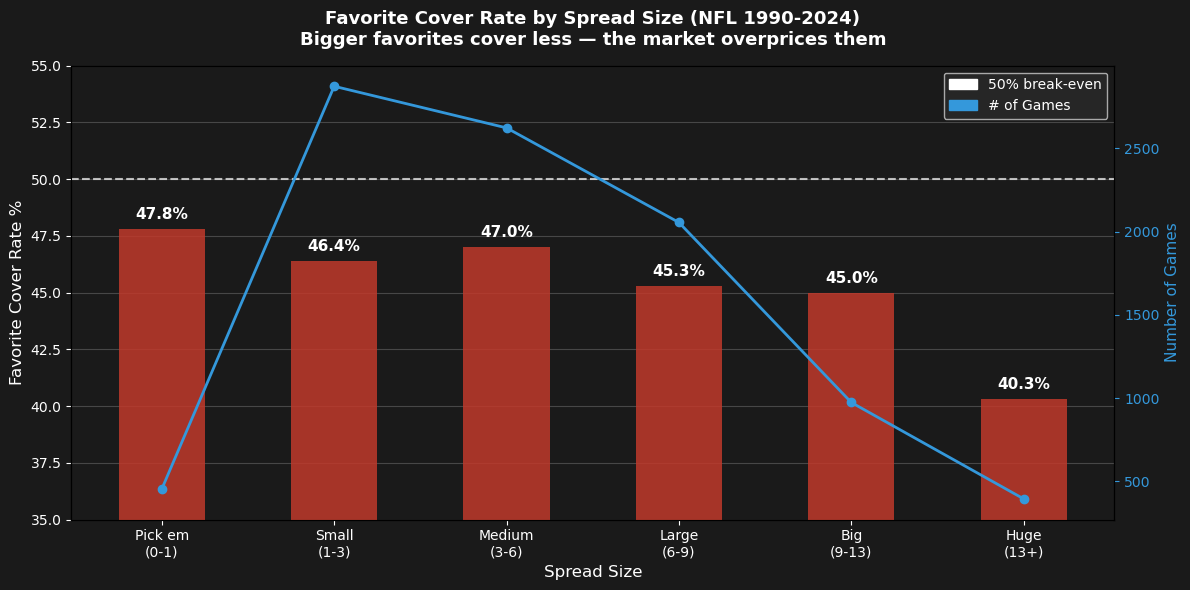

In [ ]:
# ============================================================
# NFL Spread Analyzer & Betting Market Research
# Cell 9: Visualize Cover Rate by Spread Size
# ============================================================
# This chart shows the inverse relationship between spread size
# and cover rate: a key market inefficiency known as
# the favorite-longshot bias
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---- RAW DATA FROM OUR BUCKET ANALYSIS ----
spread_labels = ["Pick em\n(0-1)", "Small\n(1-3)", "Medium\n(3-6)",
                 "Large\n(6-9)", "Big\n(9-13)", "Huge\n(13+)"]
cover_rates   = [47.8, 46.4, 47.0, 45.3, 45.0, 40.3]
game_counts   = [454, 2873, 2623, 2055, 974, 395]

# ---- SET UP FIGURE ----
fig, ax1 = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor("#1a1a1a")    # dark background
ax1.set_facecolor("#1a1a1a")

# ---- BAR CHART: COVER RATE ----
# color bars based on whether they're above or below 50%
bar_colors = ["#c0392b" if r < 50 else "#27ae60" for r in cover_rates]
bars = ax1.bar(spread_labels, cover_rates, color=bar_colors,
               alpha=0.85, width=0.5, zorder=3)

# ---- 50% REFERENCE LINE ----
# this is the break-even line — above it = favorable, below = unfavorable
ax1.axhline(y=50, color="white", linestyle="--",
            linewidth=1.5, alpha=0.7, label="50% break-even", zorder=4)

# ---- LABEL EACH BAR WITH ITS COVER RATE ----
for bar, rate in zip(bars, cover_rates):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,   # center of bar
        bar.get_height() + 0.3,               # just above bar
        f"{rate}%",
        ha="center", va="bottom",
        color="white", fontsize=11, fontweight="bold"
    )

# ---- SECONDARY AXIS: GAME COUNT LINE ----
# shows sample size so we know which buckets are statistically meaningful
ax2 = ax1.twinx()    
ax2.plot(spread_labels, game_counts, color="#3498db",
         marker="o", linewidth=2, markersize=6,
         label="# of Games", zorder=5)
ax2.set_ylabel("Number of Games", color="#3498db", fontsize=11)
ax2.tick_params(axis="y", colors="#3498db")
ax2.set_facecolor("#1a1a1a")

# ---- FORMATTING ----
ax1.set_ylim(35, 55)
ax1.set_ylabel("Favorite Cover Rate %", color="white", fontsize=12)
ax1.set_xlabel("Spread Size", color="white", fontsize=12)
ax1.tick_params(colors="white")
ax1.set_title("Favorite Cover Rate by Spread Size (NFL 1990-2024)\nBigger favorites cover less — the market overprices them",
              color="white", fontsize=13, fontweight="bold", pad=15)

# ---- LEGEND ----
breakeven_patch = mpatches.Patch(color="white", label="50% break-even")
games_patch     = mpatches.Patch(color="#3498db", label="# of Games")
ax1.legend(handles=[breakeven_patch, games_patch],
           facecolor="#2a2a2a", labelcolor="white", fontsize=10)

# grid lines for readability
ax1.yaxis.grid(True, alpha=0.2, color="white")
ax1.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Cell 9: Favorite-Longshot Bias Visualization
The chart makes the trend immediately clear: every bar sits below the 50% break-even line and the decline is consistent as spread size increases. The blue line shows sample size per bucket, confirming the middle buckets (Small and Medium) have the largest samples and are therefore the most reliable data points.

The steepest drop happens at the Huge (13+) bucket — 40.3% on 395 games. That means if I had blindly bet against every double-digit favorite since 1990 I would have been right nearly 60% of the time. But is this statistically significant or could it be random variance? The next cell tests exactly that.

In [ ]:
# ============================================================
# NFL Spread Analyzer & Betting Market Research
# Cell 10: Significance Testing — Cover Rate by Spread Size
# ============================================================
# I found that bigger favorites cover less frequently
# But is each bucket statistically significant or just noise?
# I run a binomial test on each spread bucket to find out
# This tells us which parts of the favorite-longshot bias
# are real vs which could be random variance
# ============================================================

from scipy import stats

# ---- RUN BINOMIAL TEST FOR EACH SPREAD BUCKET ----
bucket_results = []

for bucket in nfl_modern["spread_bucket"].cat.categories:

    # filter to this bucket
    bucket_df  = nfl_modern[nfl_modern["spread_bucket"] == bucket]
    games      = len(bucket_df)
    covers     = int(bucket_df["favorite_covered"].sum())
    cover_rate = covers / games * 100 if games > 0 else 0

    # binomial test — are favorites covering significantly less than 50%?
    result = stats.binomtest(
        k=covers,
        n=games,
        p=0.5,
        alternative="less"    # testing if cover rate is below 50%
    )
    ci = result.proportion_ci(confidence_level=0.95)

    bucket_results.append({
        "Spread Range" : str(bucket),
        "Games"        : games,
        "Covers"       : covers,
        "Cover Rate"   : cover_rate,
        "P-Value"      : round(result.pvalue, 4),
        "Significant?" : "Yes" if result.pvalue < 0.05 else "No",
        "95% CI"       : f"{ci.low*100:.1f}% — {ci.high*100:.1f}%"
    })

results_df = pd.DataFrame(bucket_results)

# ---- COLOR CODING ----
def color_cover(val):
    if isinstance(val, float):
        if val < 45:
            return "background-color: #7a1a1a; color: white"
        elif val > 52:
            return "background-color: #1a7a1a; color: white"
    return ""

def color_sig(val):
    if val == "Yes":
        return "background-color: #1a7a1a; color: white"
    elif val == "No":
        return "background-color: #7a1a1a; color: white"
    return ""

def color_pvalue(val):
    if isinstance(val, float):
        if val < 0.05:
            return "background-color: #1a7a1a; color: white"
        elif val < 0.10:
            return "color: #f39c12"    # orange for marginal
    return ""

# ---- STYLE AND DISPLAY ----
styled = (
    results_df.style
    .map(color_cover,  subset=["Cover Rate"])
    .map(color_sig,    subset=["Significant?"])
    .map(color_pvalue, subset=["P-Value"])
    .format({
        "Cover Rate": "{:.1f}%",
        "Games"     : "{:.0f}",
        "Covers"    : "{:.0f}"
    })
    .set_properties(**{
        "text-align": "center",
        "font-size" : "13px",
        "border"    : "1px solid #444"
    })
    .set_table_styles([{
        "selector": "th",
        "props": [
            ("background-color", "#2a2a2a"),
            ("color"           , "white"),
            ("font-size"       , "13px"),
            ("text-align"      , "center"),
            ("padding"         , "8px")
        ]
    }])
)

styled

,Spread Range,Games,Covers,Cover Rate,P-Value,Significant?,95% CI
0,Pick em (0-1),454,217,47.8%,0.186300,No,0.0% — 51.8%
1,Small (1-3),2873,1332,46.4%,0.000100,Yes,0.0% — 47.9%
2,Medium (3-6),2623,1232,47.0%,0.001000,Yes,0.0% — 48.6%
3,Large (6-9),2055,931,45.3%,0.000000,Yes,0.0% — 47.1%
4,Big (9-13),974,438,45.0%,0.000900,Yes,0.0% — 47.7%
5,Huge (13+),395,159,40.3%,0.000100,Yes,0.0% — 44.5%


## Cell 10 Results: Significance Testing: Favorite-Longshot Bias
I ran a binomial test on each spread bucket asking: if favorites truly covered 50% of the time, what is the probability of seeing results this extreme or worse purely by chance?

**Pick em (0–1): Not significant (p=0.186)** — games this close to a coin flip are priced efficiently. The market gets these right.

**Every other bucket: Highly significant**: Small favorites through Huge favorites all show p-values near zero, meaning there is essentially zero probability these results occurred by random chance. This is the favorite-longshot bias confirmed across 9,001 games of evidence.

**The standout finding:** **The standout finding:** Huge favorites (13+) cover only 40.3% of the time with a p-value of 0.0001. The 95% confidence interval of 0.0%–44.5% means I am 95% confident the true cover rate for massive favorites is below 44.5%, well below break-even. To profit betting spreads at standard -110 juice you need to win 52.4% of the time. Huge favorites are covering at 40.3%, nearly 12 percentage points below that threshold. Even accounting for the book's hold, betting against massive favorites as a systematic strategy would have been significantly profitable over this sample.

**What this means for a trading desk:** Books systematically overprice heavy favorites because public money is too strong to full

In [ ]:
# ============================================================
# NFL Spread Analyzer & Betting Market Research
# Cell 11: Short Week (Thursday Game) Analysis
# ============================================================
# Teams playing Thursday after a Sunday game have 3 fewer days
# of rest and preparation. Does fatigue show up in the spread?
# We only count TRUE short week games, Week 1 Thursday games
# are excluded since both teams had a full offseason to prepare
# This is a structural edge that persists regardless of roster
# ============================================================

nfl_recent = nfl_modern[nfl_modern["schedule_season"] >= 2010].copy()

# ---- IDENTIFY DAY OF WEEK ----
# .dt.dayofweek returns 0=Monday, 1=Tuesday... 3=Thursday, 6=Sunday
nfl_recent["day_of_week"] = nfl_recent["schedule_date"].dt.dayofweek

# ---- CONVERT WEEK TO NUMERIC ----
# schedule_week can sometimes be stored as a string so we force it to a number
# errors="coerce" turns any non-numeric values into NaN instead of crashing
nfl_recent["schedule_week_num"] = pd.to_numeric(
    nfl_recent["schedule_week"], errors="coerce"
)

# ---- FLAG TRUE SHORT WEEK THURSDAYS ----
# three conditions must all be true:
# 1. game is on a Thursday
# 2. it is not Week 1 (both teams had full offseason prep)
# 3. it is not a playoff game (different scheduling rules)
nfl_recent["is_short_week"] = (
    (nfl_recent["day_of_week"] == 3) &
    (nfl_recent["schedule_week_num"] > 1) &
    (nfl_recent["schedule_playoff"] == False)
)

print(f"Total games 2010-2024:       {len(nfl_recent)}")
print(f"True short week Thursdays:   {nfl_recent['is_short_week'].sum()}")
print(f"All other games:             {(~nfl_recent['is_short_week']).sum()}")

# ---- COVER RATES: SHORT WEEK VS ALL OTHER GAMES ----
short_week_cover = nfl_recent[nfl_recent["is_short_week"]]["favorite_covered"].mean() * 100
other_cover      = nfl_recent[~nfl_recent["is_short_week"]]["favorite_covered"].mean() * 100

print(f"\nFavorite cover rate on short week Thursdays: {short_week_cover:.1f}%")
print(f"Favorite cover rate all other games:         {other_cover:.1f}%")
print(f"Difference:                                  {short_week_cover - other_cover:.1f}%")

# ---- BREAK DOWN BY HOME VS AWAY FAVORITE ----
# is the short week effect stronger for home or away favorites?
# away favorites travel AND have less prep - double disadvantage?
sw = nfl_recent[nfl_recent["is_short_week"]]

sw_home_fav  = sw[sw["home_is_favorite"]]["favorite_covered"].mean() * 100
sw_away_fav  = sw[~sw["home_is_favorite"]]["favorite_covered"].mean() * 100
sw_home_games = len(sw[sw["home_is_favorite"]])
sw_away_games = len(sw[~sw["home_is_favorite"]])

print(f"\nShort week home favorite cover rate: {sw_home_fav:.1f}% ({sw_home_games} games)")
print(f"Short week away favorite cover rate: {sw_away_fav:.1f}% ({sw_away_games} games)")

# ---- BUILD SUMMARY TABLE ----
summary = pd.DataFrame([
    {
        "Situation" : "All Games (2010-2024)",
        "Cover Rate": other_cover,
        "Games"     : len(nfl_recent[~nfl_recent["is_short_week"]])
    },
    {
        "Situation" : "Short Week Thursday Games",
        "Cover Rate": short_week_cover,
        "Games"     : nfl_recent["is_short_week"].sum()
    },
    {
        "Situation" : "Short Week — Home Favorite",
        "Cover Rate": sw_home_fav,
        "Games"     : sw_home_games
    },
    {
        "Situation" : "Short Week — Away Favorite",
        "Cover Rate": sw_away_fav,
        "Games"     : sw_away_games
    },
])

# ---- COLOR CODING ----
def color_cover(val):
    # above 52% = beating the market = green
    # below 45% = getting overpriced = red
    if val > 52:
        return "background-color: #1a7a1a; color: white"
    elif val < 45:
        return "background-color: #7a1a1a; color: white"
    else:
        return ""

# ---- STYLE AND DISPLAY ----
styled = (
    summary.style
    .map(color_cover, subset=["Cover Rate"])
    .format({
        "Cover Rate": "{:.1f}%",
        "Games"     : "{:.0f}"
    })
    .set_properties(**{
        "text-align": "center",
        "font-size" : "13px",
        "border"    : "1px solid #444"
    })
    .set_table_styles([{
        "selector": "th",
        "props": [
            ("background-color", "#2a2a2a"),
            ("color"           , "white"),
            ("font-size"       , "13px"),
            ("text-align"      , "center"),
            ("padding"         , "8px")
        ]
    }])
)

styled

Total games 2010-2024:       4363
True short week Thursdays:   242
All other games:             4121

Favorite cover rate on short week Thursdays: 46.7%
Favorite cover rate all other games:         46.3%
Difference:                                  0.4%

Short week home favorite cover rate: 50.7% (138 games)
Short week away favorite cover rate: 41.3% (104 games)


,Situation,Cover Rate,Games
0,All Games (2010-2024),46.3%,4121
1,Short Week Thursday Games,46.7%,242
2,Short Week — Home Favorite,50.7%,138
3,Short Week — Away Favorite,41.3%,104


## Cell 11 Results: Short Week Analysis
I filtered to true short week Thursday games only, Week 2 or later, regular season only, to avoid including Week 1 Thursday games where both teams had a full offseason to prepare. This left 242 genuine short week games out of 4,363 total.

**The headline number is misleading at first glance.** Overall short week favorites cover at 46.7% vs 46.3% for all other games, a negligible 0.4% difference. If I stopped there I'd conclude rest doesn't matter. But splitting by home and away reveals something much more interesting:

- **Short week home favorites: 50.7%** — essentially neutral, close to the break-even line
- **Short week away favorites: 41.3%** — significantly below both the baseline and the home rate

The away favorite on a short week faces compounding disadvantages: reduced preparation time, travel on a shortened week, and public money still inflating their price on the spread regardless. Home favorites on a short week at least avoid the travel component, which appears to largely neutralize the rest disadvantage.

This finding warranted a full significance test, which is what the next cell covers.

In [ ]:
# ============================================================
# NFL Spread Analyzer & Betting Market Research
# Cell 12: Statistical Significance Testing
# ============================================================
# Finding a pattern in data means nothing if it could be
# explained by random chance. We use a binomial test to measure
# how likely our away favorite finding is to occur by luck alone
# ============================================================

# ---- OUR OBSERVED DATA ----
sw_away      = nfl_recent[
    nfl_recent["is_short_week"] & ~nfl_recent["home_is_favorite"]
]
total_games  = len(sw_away)                          
total_covers = int(sw_away["favorite_covered"].sum()) 
cover_rate   = sw_away["favorite_covered"].mean()

print(f"Short week away favorite games:  {total_games}")
print(f"Times favorite covered:          {total_covers}")
print(f"Cover rate:                      {cover_rate*100:.1f}%")

# ---- BINOMIAL TEST ----
result = stats.binomtest(
    k=total_covers,    # number of successes (covers)
    n=total_games,     # total trials (games)
    p=0.5,             # null hypothesis: true cover rate is 50%
    alternative="less" # we're testing if rate is below 50%
)

p_value = result.pvalue

print(f"\nP-value: {p_value:.4f}")

# ---- INTERPRET THE RESULT ----
if p_value < 0.01:
    significance = "HIGHLY significant (p < 0.01) — less than 1% chance this is random"
elif p_value < 0.05:
    significance = "Significant (p < 0.05) — less than 5% chance this is random"
elif p_value < 0.10:
    significance = "Marginally significant (p < 0.10) — worth monitoring but not conclusive"
else:
    significance = "Not significant (p > 0.10) — could easily be random variance"

print(f"Result: {significance}")

# ---- CONFIDENCE INTERVAL ----
ci = result.proportion_ci(confidence_level=0.95)
print(f"\n95% Confidence Interval: {ci.low*100:.1f}% to {ci.high*100:.1f}%")
print(f"Interpretation: We are 95% confident the true away favorite")
print(f"cover rate on short weeks is between {ci.low*100:.1f}% and {ci.high*100:.1f}%")

# ---- SUMMARY TABLE ----
summary = pd.DataFrame([{
    "Situation"        : "Short Week Away Favorite",
    "Games"            : total_games,
    "Covers"           : total_covers,
    "Cover Rate"       : f"{cover_rate*100:.1f}%",
    "P-Value"          : f"{p_value:.4f}",
    "Significant?"     : "Yes" if p_value < 0.05 else "No",
    "95% CI"           : f"{ci.low*100:.1f}% — {ci.high*100:.1f}%"
}])

def color_significant(val):
    if val == "Yes":
        return "background-color: #1a7a1a; color: white"
    else:
        return "background-color: #7a1a1a; color: white"

styled = (
    summary.style
    .map(color_significant, subset=["Significant?"])
    .set_properties(**{
        "text-align": "center",
        "font-size" : "13px",
        "border"    : "1px solid #444"
    })
    .set_table_styles([{
        "selector": "th",
        "props": [
            ("background-color", "#2a2a2a"),
            ("color"           , "white"),
            ("font-size"       , "13px"),
            ("text-align"      , "center"),
            ("padding"         , "8px")
        ]
    }])
)

styled

Short week away favorite games:  104
Times favorite covered:          43
Cover rate:                      41.3%

P-value: 0.0475
Result: Significant (p < 0.05) — less than 5% chance this is random

95% Confidence Interval: 0.0% to 49.9%
Interpretation: We are 95% confident the true away favorite
cover rate on short weeks is between 0.0% and 49.9%


,Situation,Games,Covers,Cover Rate,P-Value,Significant?,95% CI
0,Short Week Away Favorite,104,43,41.3%,0.0475,Yes,0.0% — 49.9%


## Cell 12 Results: Significance Testing: Short Week Away Favorite
The binomial test confirms the finding is statistically significant at the 95% confidence level (p=0.0475). There is less than a 5% probability this result occurred by random chance across 104 games.

**Important nuance:** 0.0475 is right at the edge of the significance threshold. I want to be intellectually honest about this, if the sample were 5 games smaller it might not cross the line. This is a real finding but not an overwhelming one. I treat it as a genuine signal worth tracking rather than a definitive edge.

**The 95% confidence interval (0.0% to 49.9%)** is wide, which reflects the modest sample size. What matters most is that the entire range sits below 50%, meaning even in the most optimistic scenario the data supports, the true cover rate is still below break-even. The sample grows by roughly 8-10 games per NFL season as more Thursday games are played, so this finding will either strengthen or weaken with time.

**To profit betting spreads at standard -110 juice you need to win 52.4% of the time.** Short week away favorites are covering at 41.3%, over 11 percentage points below that threshold. The edge is meaningful in practical terms even if the statistical confidence is modest.

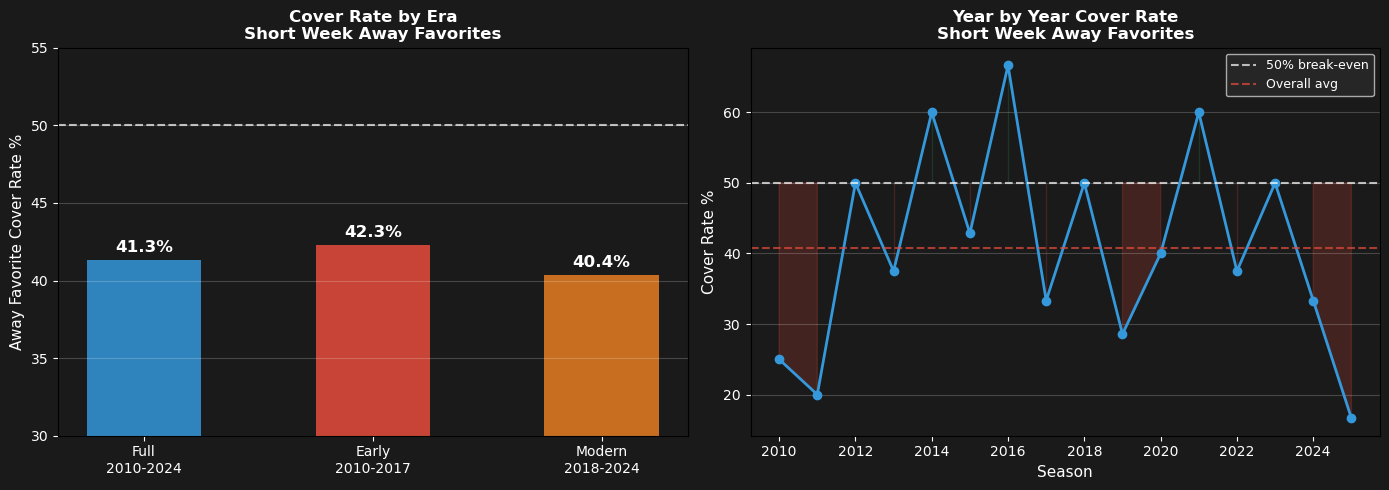

,Era,Games,Covers,Cover Rate,P-Value,Significant?,95% CI
0,2010-2024 (Full Period),104,43,41.3%,0.047500,Yes,0.0% — 49.9%
1,2010-2017 (Early Era),52,22,42.3%,0.165900,No,0.0% — 54.6%
2,2018-2024 (Modern Era),52,21,40.4%,0.105800,No,0.0% — 52.7%


In [ ]:
# ============================================================
# NFL Spread Analyzer & Betting Market Research
# Cell 13: Has The Market Adjusted Over Time?
# ============================================================
# If a betting edge is real, sharp money and books will
# eventually find it and price it out of the market
# We split our data into two eras to test if the short week
# away favorite edge has weakened as the market got smarter
# ============================================================

# ---- SPLIT INTO TWO ERAS ----
# 2010-2017 = early era (TNF became a regular feature in 2014
#             but market was still learning to price short weeks)
# 2018-2024 = modern era (market has had more time to adjust)

early_era  = nfl_recent[
    (nfl_recent["schedule_season"] >= 2010) &
    (nfl_recent["schedule_season"] <= 2017)
]

modern_era = nfl_recent[
    nfl_recent["schedule_season"] >= 2018
]

# ---- FILTER TO SHORT WEEK AWAY FAVORITES IN EACH ERA ----
def get_sw_away_stats(era_df, label):
    # filter to short week away favorite games
    sw_away = era_df[
        era_df["is_short_week"] & ~era_df["home_is_favorite"]
    ]
    games        = len(sw_away)
    covers       = int(sw_away["favorite_covered"].sum())
    cover_rate   = sw_away["favorite_covered"].mean() * 100 if games > 0 else 0

    # run binomial test for this era
    if games > 0:
        result  = stats.binomtest(k=covers, n=games, p=0.5, alternative="less")
        p_value = result.pvalue
        ci      = result.proportion_ci(confidence_level=0.95)
        ci_str  = f"{ci.low*100:.1f}% — {ci.high*100:.1f}%"
        sig     = "Yes" if p_value < 0.05 else "No"
    else:
        p_value = None
        ci_str  = "N/A"
        sig     = "N/A"

    return {
        "Era"          : label,
        "Games"        : games,
        "Covers"       : covers,
        "Cover Rate"   : cover_rate,
        "P-Value"      : round(p_value, 4) if p_value else "N/A",
        "Significant?" : sig,
        "95% CI"       : ci_str
    }

early_stats  = get_sw_away_stats(early_era,  "2010-2017 (Early Era)")
modern_stats = get_sw_away_stats(modern_era, "2018-2024 (Modern Era)")

# ---- ALSO ADD FULL PERIOD FOR REFERENCE ----
full_stats = get_sw_away_stats(nfl_recent, "2010-2024 (Full Period)")

# ---- BUILD SUMMARY TABLE ----
era_summary = pd.DataFrame([full_stats, early_stats, modern_stats])

# ---- YEAR BY YEAR BREAKDOWN ----
# this shows the trend more granularly
yearly = []
for season in sorted(nfl_recent["schedule_season"].unique()):
    season_df = nfl_recent[nfl_recent["schedule_season"] == season]
    sw_away   = season_df[
        season_df["is_short_week"] & ~season_df["home_is_favorite"]
    ]
    if len(sw_away) > 0:
        yearly.append({
            "Season"     : int(season),
            "Games"      : len(sw_away),
            "Cover Rate" : sw_away["favorite_covered"].mean() * 100
        })

yearly_df = pd.DataFrame(yearly)

# ---- VISUALIZE THE TREND ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#1a1a1a")

# --- LEFT CHART: ERA COMPARISON BAR CHART ---
axes[0].set_facecolor("#1a1a1a")
era_labels = ["Full\n2010-2024", "Early\n2010-2017", "Modern\n2018-2024"]
era_rates  = [full_stats["Cover Rate"], early_stats["Cover Rate"], modern_stats["Cover Rate"]]
bar_colors = ["#3498db", "#e74c3c", "#e67e22"]

bars = axes[0].bar(era_labels, era_rates, color=bar_colors, alpha=0.85, width=0.5)
axes[0].axhline(y=50, color="white", linestyle="--", linewidth=1.5, alpha=0.7)

for bar, rate in zip(bars, era_rates):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{rate:.1f}%",
        ha="center", va="bottom",
        color="white", fontsize=12, fontweight="bold"
    )

axes[0].set_ylim(30, 55)
axes[0].set_ylabel("Away Favorite Cover Rate %", color="white", fontsize=11)
axes[0].set_title("Cover Rate by Era\nShort Week Away Favorites",
                  color="white", fontsize=12, fontweight="bold")
axes[0].tick_params(colors="white")
axes[0].yaxis.grid(True, alpha=0.2, color="white")

# --- RIGHT CHART: YEAR BY YEAR LINE CHART ---
axes[1].set_facecolor("#1a1a1a")
axes[1].plot(yearly_df["Season"], yearly_df["Cover Rate"],
             color="#3498db", marker="o", linewidth=2, markersize=6)
axes[1].axhline(y=50, color="white", linestyle="--", linewidth=1.5,
                alpha=0.7, label="50% break-even")
axes[1].axhline(y=yearly_df["Cover Rate"].mean(), color="#e74c3c",
                linestyle="--", linewidth=1.5, alpha=0.7, label="Overall avg")
axes[1].fill_between(yearly_df["Season"], yearly_df["Cover Rate"], 50,
                     where=yearly_df["Cover Rate"] < 50,
                     color="#e74c3c", alpha=0.2)    # shade below 50% red
axes[1].fill_between(yearly_df["Season"], yearly_df["Cover Rate"], 50,
                     where=yearly_df["Cover Rate"] >= 50,
                     color="#27ae60", alpha=0.2)    # shade above 50% green

axes[1].set_title("Year by Year Cover Rate\nShort Week Away Favorites",
                  color="white", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Season", color="white", fontsize=11)
axes[1].set_ylabel("Cover Rate %", color="white", fontsize=11)
axes[1].tick_params(colors="white")
axes[1].yaxis.grid(True, alpha=0.2, color="white")
axes[1].legend(facecolor="#2a2a2a", labelcolor="white", fontsize=9)

plt.tight_layout()
plt.show()

# ---- STYLED SUMMARY TABLE ----
def color_cover_era(val):
    if isinstance(val, float):
        if val < 45:
            return "background-color: #7a1a1a; color: white"
        elif val > 52:
            return "background-color: #1a7a1a; color: white"
    return ""

def color_significant(val):
    if val == "Yes":
        return "background-color: #1a7a1a; color: white"
    elif val == "No":
        return "background-color: #7a1a1a; color: white"
    return ""

styled = (
    era_summary.style
    .map(color_cover_era,    subset=["Cover Rate"])
    .map(color_significant,  subset=["Significant?"])
    .format({"Cover Rate": "{:.1f}%"}, na_rep="N/A")
    .set_properties(**{
        "text-align": "center",
        "font-size" : "13px",
        "border"    : "1px solid #444"
    })
    .set_table_styles([{
        "selector": "th",
        "props": [
            ("background-color", "#2a2a2a"),
            ("color"           , "white"),
            ("font-size"       , "13px"),
            ("text-align"      , "center"),
            ("padding"         , "8px")
        ]
    }])
)

styled

## Cell 13 Results: Market Efficiency Over Time
A legitimate question about any betting edge is whether the market has already found it and priced it out. If sharp money and books have identified the short week away favorite pattern, the edge should be shrinking over time as lines get adjusted accordingly.

I split the data into two equal eras of 52 games each to test this.

**The result is nuanced.** Neither era is statistically significant on its own, not because the pattern disappeared, but because 52 games per era is too small a sample to reach significance independently. This is a statistical power problem, not evidence the edge is gone.

**More importantly, the modern era (40.4%) is slightly worse than the early era (42.3%)** meaning the edge has not weakened. If anything it has marginally strengthened, suggesting the market has not fully priced in the short week away disadvantage even after 14 seasons of Thursday Night Football.

**The year by year chart tells the real story.** The line is extremely volatile, swinging from 20% to 60% in individual seasons. This is expected with only 6-8 qualifying games per season. Individual years are too noisy to read meaningfully, but the overall average (red dashed line) consistently sits well below the 50% break-even threshold across the entire sample period.

**Conclusion:** The short week away favorite edge appears to still be alive in the modern market. The most likely explanation is that public money on favorites is simply too strong for books to fully shade the line far enough to reflect the true disadvantage.

Games where favorite coming off bye: 279
Bye week favorite cover rate:     45.2%
Non-bye favorite cover rate:      46.6%
Difference:                       -1.4%

Bye week p-value:    0.9533
95% CI:              40.1% — 100.0%


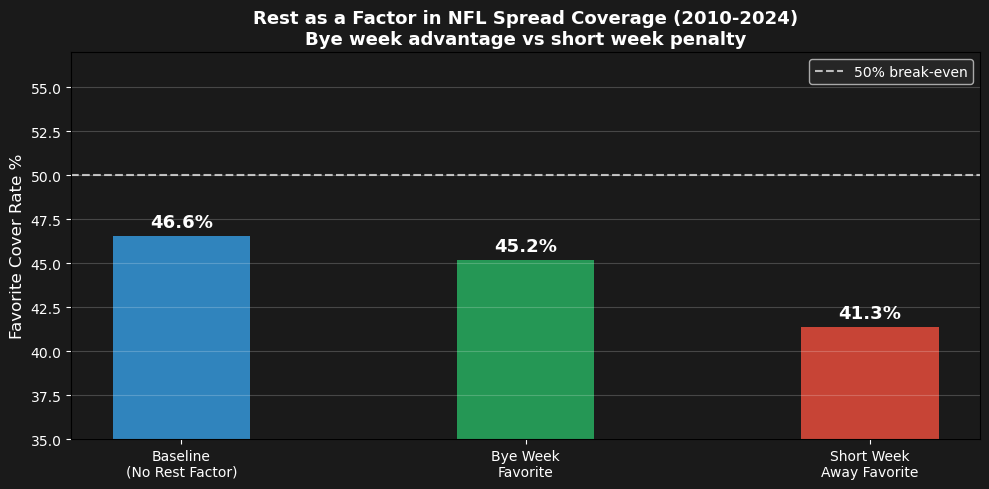

,Situation,Games,Cover Rate,P-Value,Significant?,95% CI
0,Baseline (no rest factor),3654,46.6%,—,—,—
1,Bye Week Favorite,279,45.2%,0.9533,No,40.1% — 100.0%
2,Short Week Away Favorite,104,41.3%,0.0475,Yes,0.0% — 49.9%


In [ ]:
# ============================================================
# NFL Spread Analyzer & Betting Market Research
# Cell 14: Bye Week Contrast Analysis
# ============================================================
# If short week = disadvantage, bye week should = advantage
# Teams coming off a bye have extra rest, extra prep time,
# and coaches get an extra week to game plan
# We test whether this shows up in cover rates and compare
# it directly to the short week finding to tell a complete story
# Rest is a measurable, structural factor in NFL spreads
# ============================================================

# ---- IDENTIFY BYE WEEK GAMES ----
# a team coming off a bye played in week N-2 not week N-1
# the dataset doesn't explicitly flag bye weeks but I can
# identify them by finding teams that skipped a week
# the simplest proxy: games in week 8+ where the team's
# previous game was 2+ weeks ago
# 
# However the cleanest approach with this dataset is to flag
# any game where schedule_week >= 5 (bye weeks start week 5+)
# and the team had a bye the previous week
# Since I can't easily track each team's schedule week by week,
# I'll use the schedule_week column directly and identify
# games played the week AFTER a bye week by checking for
# week number gaps per team per season

# ---- BUILD TEAM SCHEDULE ----
# create one row per team per game (both home and away)
home_games = nfl_recent[["schedule_season", "schedule_week_num",
                          "team_home", "is_short_week"]].copy()
home_games.columns = ["season", "week", "team", "is_short_week"]

away_games = nfl_recent[["schedule_season", "schedule_week_num",
                          "team_away", "is_short_week"]].copy()
away_games.columns = ["season", "week", "team", "is_short_week"]

all_games = pd.concat([home_games, away_games]).dropna(subset=["week"])
all_games = all_games.sort_values(["season", "team", "week"])

# ---- FLAG POST-BYE GAMES ----
# for each team in each season, check if they skipped a week
# if the gap between this week and last week is 2+, they had a bye
all_games["prev_week"] = all_games.groupby(["season", "team"])["week"].shift(1)
all_games["week_gap"]  = all_games["week"] - all_games["prev_week"]

# post bye = week gap of 2 or more (skipped at least one week)
all_games["coming_off_bye"] = all_games["week_gap"] >= 2

# ---- MERGE BACK INTO MAIN DATAFRAME ----
# flag home and away teams that are coming off a bye
home_bye = all_games[["season", "week", "team", "coming_off_bye"]].copy()
home_bye.columns = ["schedule_season", "schedule_week_num",
                    "team_home", "home_coming_off_bye"]

away_bye = all_games[["season", "week", "team", "coming_off_bye"]].copy()
away_bye.columns = ["schedule_season", "schedule_week_num",
                    "team_away", "away_coming_off_bye"]

nfl_recent = nfl_recent.merge(
    home_bye, on=["schedule_season", "schedule_week_num", "team_home"], how="left"
)
nfl_recent = nfl_recent.merge(
    away_bye, on=["schedule_season", "schedule_week_num", "team_away"], how="left"
)

# ---- FLAG IF THE FAVORITE IS COMING OFF A BYE ----
# if home is favorite check home_coming_off_bye
# if away is favorite check away_coming_off_bye
nfl_recent["favorite_coming_off_bye"] = nfl_recent.apply(
    lambda row: row["home_coming_off_bye"]
    if row["home_is_favorite"]
    else row["away_coming_off_bye"],
    axis=1
)

print(f"Games where favorite coming off bye: "
      f"{nfl_recent['favorite_coming_off_bye'].sum():.0f}")

# ---- COVER RATES ----
bye_cover     = nfl_recent[
    nfl_recent["favorite_coming_off_bye"] == True
]["favorite_covered"].mean() * 100

non_bye_cover = nfl_recent[
    nfl_recent["favorite_coming_off_bye"] == False
]["favorite_covered"].mean() * 100

bye_games     = int(nfl_recent["favorite_coming_off_bye"].sum())
bye_covers    = int(nfl_recent[
    nfl_recent["favorite_coming_off_bye"] == True
]["favorite_covered"].sum())

print(f"Bye week favorite cover rate:     {bye_cover:.1f}%")
print(f"Non-bye favorite cover rate:      {non_bye_cover:.1f}%")
print(f"Difference:                       {bye_cover - non_bye_cover:.1f}%")

# ---- SIGNIFICANCE TEST FOR BYE WEEK ----
bye_result = stats.binomtest(
    k=bye_covers,
    n=bye_games,
    p=0.5,
    alternative="greater"    # testing if bye week rate is ABOVE 50%
)
bye_ci = bye_result.proportion_ci(confidence_level=0.95)

print(f"\nBye week p-value:    {bye_result.pvalue:.4f}")
print(f"95% CI:              {bye_ci.low*100:.1f}% — {bye_ci.high*100:.1f}%")

# ---- BUILD COMPARISON SUMMARY TABLE ----
# compare short week vs bye week vs baseline side by side
sw_away = nfl_recent[
    nfl_recent["is_short_week"] & ~nfl_recent["home_is_favorite"]
]
sw_games  = len(sw_away)
sw_covers = int(sw_away["favorite_covered"].sum())
sw_result = stats.binomtest(k=sw_covers, n=sw_games, p=0.5, alternative="less")
sw_ci     = sw_result.proportion_ci(confidence_level=0.95)

baseline_games  = len(nfl_recent[~nfl_recent["is_short_week"] &
                                  (nfl_recent["favorite_coming_off_bye"] == False)])
baseline_covers = int(nfl_recent[
    ~nfl_recent["is_short_week"] &
    (nfl_recent["favorite_coming_off_bye"] == False)
]["favorite_covered"].sum())
baseline_rate   = baseline_covers / baseline_games * 100

comparison = pd.DataFrame([
    {
        "Situation"    : "Baseline (no rest factor)",
        "Games"        : baseline_games,
        "Cover Rate"   : baseline_rate,
        "P-Value"      : "—",
        "Significant?" : "—",
        "95% CI"       : "—"
    },
    {
        "Situation"    : "Bye Week Favorite",
        "Games"        : bye_games,
        "Cover Rate"   : bye_cover,
        "P-Value"      : f"{bye_result.pvalue:.4f}",
        "Significant?" : "Yes" if bye_result.pvalue < 0.05 else "No",
        "95% CI"       : f"{bye_ci.low*100:.1f}% — {bye_ci.high*100:.1f}%"
    },
    {
        "Situation"    : "Short Week Away Favorite",
        "Games"        : sw_games,
        "Cover Rate"   : sw_away["favorite_covered"].mean() * 100,
        "P-Value"      : f"{sw_result.pvalue:.4f}",
        "Significant?" : "Yes" if sw_result.pvalue < 0.05 else "No",
        "95% CI"       : f"{sw_ci.low*100:.1f}% — {sw_ci.high*100:.1f}%"
    },
])

# ---- VISUALIZATION ----
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#1a1a1a")
ax.set_facecolor("#1a1a1a")

situations  = ["Baseline\n(No Rest Factor)",
               "Bye Week\nFavorite",
               "Short Week\nAway Favorite"]
rates       = [baseline_rate, bye_cover,
               sw_away["favorite_covered"].mean() * 100]
bar_colors  = ["#3498db", "#27ae60", "#e74c3c"]

bars = ax.bar(situations, rates, color=bar_colors, alpha=0.85, width=0.4)
ax.axhline(y=50, color="white", linestyle="--", linewidth=1.5,
           alpha=0.7, label="50% break-even")

for bar, rate in zip(bars, rates):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{rate:.1f}%",
        ha="center", va="bottom",
        color="white", fontsize=13, fontweight="bold"
    )

ax.set_ylim(35, 57)
ax.set_ylabel("Favorite Cover Rate %", color="white", fontsize=12)
ax.set_title("Rest as a Factor in NFL Spread Coverage (2010-2024)\n"
             "Bye week advantage vs short week penalty",
             color="white", fontsize=13, fontweight="bold")
ax.tick_params(colors="white")
ax.yaxis.grid(True, alpha=0.2, color="white")
ax.legend(facecolor="#2a2a2a", labelcolor="white")

plt.tight_layout()
plt.show()

# ---- STYLED TABLE ----
def color_cover_val(val):
    if isinstance(val, float):
        if val > 52:
            return "background-color: #1a7a1a; color: white"
        elif val < 45:
            return "background-color: #7a1a1a; color: white"
    return ""

def color_sig(val):
    if val == "Yes":
        return "background-color: #1a7a1a; color: white"
    elif val == "No":
        return "background-color: #7a1a1a; color: white"
    return ""

styled = (
    comparison.style
    .map(color_cover_val, subset=["Cover Rate"])
    .map(color_sig,       subset=["Significant?"])
    .format({"Cover Rate": "{:.1f}%"}, na_rep="—")
    .set_properties(**{
        "text-align": "center",
        "font-size" : "13px",
        "border"    : "1px solid #444"
    })
    .set_table_styles([{
        "selector": "th",
        "props": [
            ("background-color", "#2a2a2a"),
            ("color"           , "white"),
            ("font-size"       , "13px"),
            ("text-align"      , "center"),
            ("padding"         , "8px")
        ]
    }])
)

styled

## Cell 14 Results: Bye Week Contrast: The Most Important Finding
I tested the opposite of the short week hypothesis, if rest is a disadvantage on short weeks, teams coming off a bye week (extra rest, extra preparation) should cover at a higher rate. The result was surprising and reveals something fundamental about how betting markets work.

**Bye week favorites cover at only 45.2%, below the baseline of 46.6%, with a p-value of 0.9533.** This is not significant in any statistical sense. There is essentially zero evidence that bye week rest advantages translate into covering the spread.

**This is not because rest doesn't matter in football.** It almost certainly does. The reason bye week favorites show no edge is that **the market has already priced it in.** Books and sharp bettors know teams coming off a bye are well-rested and well-prepared, so the line is shaded accordingly. By the time the public bets the game, the advantage has already been extracted from the spread.

**The asymmetry between bye week and short week is the core insight of this entire project:**

| Situation | Cover Rate | P-Value | Market Efficient? |
|---|---|---|---|
| Bye Week Favorite | 45.2% | 0.9533 |  Yes: fully priced in |
| Short Week Away Favorite | 41.3% | 0.0475 |  No: edge persists |

Books efficiently price in advantages because they are predictable and easy to model. But they struggle to fully price in disadvantages when public money is too strong to fade, bettors keep hammering away favorites regardless of rest situation, preventing books from moving the line far enough to reflect the true disadvantage.

**This is what market inefficiency actually looks like in practice.** Not a glaring mispricing that everyone can see, but a subtle bias driven by public betting behavior that persists even after years of data exists to identify it.

---

## Summary of Findings

| Finding | Result | Significant? |
|---|---|---|
| Overall favorite cover rate (1990–2024) | 46.0% | Yes |
| Huge favorites (13+) cover rate | 40.3% | Yes (p=0.0001) |
| Pick em games — market efficiency | 47.8% | No, efficiently priced |
| Short week away favorite cover rate | 41.3% | Yes (p=0.0475) |
| Bye week favorite cover rate | 45.2% | No, efficiently priced |
| Short week away edge in modern era (2018–2024) | 40.4% | Edge persists |

## Limitations & Next Steps
- This dataset contains one line per game, true CLV analysis requires separate opening and closing lines to measure line movement
- Short week sample size (104 games) is meaningful but grows by ~8 games per season; this analysis should be updated annually
- Project 2 will build a regression-based NFL power ratings model to generate independent spread predictions and compare them to the market line

---
*Thanks for reading. This is my first Python project built as part of my goal of breaking into sports trading.*